# NB07 — Redes Neuronales Profundas (Unidad III)

**Cobertura del syllabus — Unidad III · Fundamentos de Redes Neuronales Artificiales:**
- Modelo de neurona artificial (perceptrón)
- Redes neuronales superficiales (1 capa oculta)
- Redes neuronales profundas (5+ capas con BatchNorm + Dropout)
- Algoritmos de entrenamiento: comparación Adam vs SGD vs RMSprop
- Aplicaciones: predicción de rendimiento de café

**Datos:** `master_cafe_municipal_mensual.csv` (generado tras cargar BD).

**Comparación:** MLP profundo vs XGBoost (NB02 baseline 2da entrega).

**Métricas esperadas:** R² > 0.5 (vs 0.067 baseline) — mejora viene de más datos municipales.

In [44]:
# 0. Setup
import os, sys, warnings, json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
tf.get_logger().setLevel('ERROR')
warnings.filterwarnings('ignore')

RNG = 123
np.random.seed(RNG); tf.random.set_seed(RNG)

PROJECT = Path('..').resolve()
DIR_DATOS = PROJECT / '01_datos' / 'procesados'
DIR_MODELS = PROJECT / '04_modelos_entrenados'; DIR_MODELS.mkdir(parents=True, exist_ok=True)
DIR_FIG = PROJECT / '05_resultados' / 'figuras'; DIR_FIG.mkdir(parents=True, exist_ok=True)
DIR_TABLAS = PROJECT / '05_resultados' / 'tablas'; DIR_TABLAS.mkdir(parents=True, exist_ok=True)

print('TF version:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

TF version: 2.21.0
GPU disponible: []


## 1. Carga de datos · 2 alternativas

1. **Vía CSV** (si todavía no se cargó la BD): `master_cafe_municipal_mensual.csv`
2. **Vía PostgreSQL** (recomendado): query a `cafe.vw_master_municipal_mensual`

In [56]:
# Opción A: CSV
# csv_master = DIR_DATOS / 'master_cafe_municipal_mensual.csv'
# csv_2da    = PROJECT.parent / 'IA_Segunda_Entrega' / 'datasets' / 'master_cafe_semestral.csv' # alternativa para usar el master semestral (2da entrega)
# 
# if csv_master.exists():
#     df = pd.read_csv(csv_master)
#     print('master municipal:', df.shape)
# elif csv_2da.exists():
#     df = pd.read_csv(csv_2da)
#     print('usando master semestral (2da entrega):', df.shape)
# else:
#     raise FileNotFoundError('Sin master_cafe_*.csv — corre primero NB04 o BD')

# Opción B (alternativa): vía Postgres
import psycopg2
conn = psycopg2.connect(host='localhost', user='postgres', password='root', dbname='cafe_ia')
df = pd.read_sql('SELECT * FROM cafe.vw_master_municipal_mensual', conn)

print(df.dtypes.value_counts())
df.head()

float64    21
object     12
int64       3
bool        1
Name: count, dtype: int64


,cod_mun,municipio,departamento,altitud_msnm,zona_cafetera,soil_ph,soil_soc_pct,fecha,anio,mes,...,ndvi,precio_fnc_cop_kg,precio_arabica_brasil_usd_kg,precio_robusta_usd_kg,precio_arabica_wb_usd_kg,precio_arabica_brasil_cop_kg,fnc_cosecha_60kg,fnc_export_60kg,trm_cop_usd,surge_flag
0,05001,Medellin,Antioquia,1481.0,None,5.00,88.45,1990-01-01,1990,1,...,None,NaN,NaN,NaN,1.6761,NaN,None,None,NaN,False
1,15001,Tunja,Boyaca,2694.0,None,6.25,51.57,1990-01-01,1990,1,...,None,NaN,NaN,NaN,1.6761,NaN,None,None,NaN,False
2,17001,Manizales,Caldas,2107.0,None,5.40,66.05,1990-01-01,1990,1,...,None,NaN,NaN,NaN,1.6761,NaN,None,None,NaN,False
3,17442,Marsella,Caldas,1544.0,None,5.32,40.87,1990-01-01,1990,1,...,None,NaN,NaN,NaN,1.6761,NaN,None,None,NaN,False
4,17653,Salamina,Caldas,1781.0,None,5.10,73.72,1990-01-01,1990,1,...,None,NaN,NaN,NaN,1.6761,NaN,None,None,NaN,False


In [57]:
# 2. Preparación de features
# Target: rendimiento_ton_ha
TARGET = 'rendimiento_ton_ha'

# Columnas a excluir (identificadores y target)
EXCLUIR = {TARGET, 'cod_mun', 'municipio', 'departamento', 'fecha', 'estado_fisico'}

# Detectar columnas numéricas
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in EXCLUIR]
cat_cols = [c for c in df.select_dtypes(include=['object','category']).columns if c not in EXCLUIR]

print(f'Numéricas: {len(num_cols)} | Categóricas: {len(cat_cols)}')
print('Numéricas:', num_cols)

# Limpiar nulos en target
# df = df.dropna(subset=[TARGET]).reset_index(drop=True)
# print(f'Filas con target válido: {len(df)}')

#
# Limpiar nulos y valores inválidos del target
df = df.dropna(subset=[TARGET]).copy()

# evitar divisiones absurdas
df = df[np.isfinite(df[TARGET])]

# remover outliers extremos
q1 = df[TARGET].quantile(0.01)
q99 = df[TARGET].quantile(0.99)

df = df[
    (df[TARGET] >= q1) &
    (df[TARGET] <= q99)
].reset_index(drop=True)

print(f'Filas con target válido: {len(df)}')
print(df[TARGET].describe())
#

# Encoding categóricas
for c in cat_cols:
    df[c + '_enc'] = LabelEncoder().fit_transform(df[c].astype(str))
    num_cols.append(c + '_enc')

X = df[num_cols].copy().fillna(df[num_cols].median(numeric_only=True))
y = df[TARGET].copy()

print('Shape final:', X.shape, y.shape)

Numéricas: 23 | Categóricas: 7
Numéricas: ['altitud_msnm', 'soil_ph', 'soil_soc_pct', 'anio', 'mes', 'semestre', 'oni', 'area_sembrada_ha', 'area_cosechada_ha', 'produccion_ton', 'temp_media_c', 'temp_min_c', 'temp_max_c', 'precipitacion_mm', 'et0_mm', 'viento_max_kmh', 'radiacion_mj_m2', 'precio_fnc_cop_kg', 'precio_arabica_brasil_usd_kg', 'precio_robusta_usd_kg', 'precio_arabica_wb_usd_kg', 'precio_arabica_brasil_cop_kg', 'trm_cop_usd']
Filas con target válido: 7097
count    7097.000000
mean        0.913504
std         0.293991
min         0.270000
25%         0.690000
50%         0.920000
75%         1.100000
max         1.820000
Name: rendimiento_ton_ha, dtype: float64
Shape final: (7097, 30) (7097,)


In [ ]:
# Split temporal (sin leakage)

train_mask = df['anio'] <= 2016
test_mask  = df['anio'] > 2016

X_train = X.loc[train_mask]
X_test  = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test  = y.loc[test_mask]

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

# Escalado
scaler_X = StandardScaler()

X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

# Escalar target (MUY IMPORTANTE EN MLP)
scaler_y = StandardScaler()

y_train_s = scaler_y.fit_transform(
    y_train.values.reshape(-1,1)
).ravel()

y_test_s = scaler_y.transform(
    y_test.values.reshape(-1,1)
).ravel()

print(f'Train: {X_train_s.shape}  Test: {X_test_s.shape}')

Train: (6026, 30)  Test: (1200, 30)


## 3. Modelo 1: Perceptrón simple (neurona artificial)
Implementación didáctica del modelo más básico — Unidad III.

In [48]:
def perceptron_simple(input_dim: int) -> tf.keras.Model:
    """Una sola neurona — el modelo más básico de la Unidad III."""
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(1, activation='linear', name='neurona_unica')(inp)
    return models.Model(inp, x, name='perceptron')

modelo_perc = perceptron_simple(X_train_s.shape[1])
modelo_perc.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo_perc.summary()

Model: "perceptron"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ neurona_unica (Dense)           │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Modelo 2: Red superficial (1 capa oculta)

In [49]:
def red_superficial(input_dim: int, hidden: int = 32) -> tf.keras.Model:
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(hidden, activation='relu')(inp)
    x = layers.Dense(1, activation='linear')(x)
    return models.Model(inp, x, name='red_superficial')

modelo_sup = red_superficial(X_train_s.shape[1])
modelo_sup.compile(optimizer='adam', loss='mse', metrics=['mae'])
modelo_sup.summary()

Model: "red_superficial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Modelo 3: Red profunda (5 capas + BatchNorm + Dropout + L2)
Implementa todas las técnicas de regularización del syllabus.

In [53]:
def red_profunda(input_dim: int) -> tf.keras.Model:
    """
    MLP profundo con técnicas modernas:
      - 5 capas ocultas (256→128→64→32→16)
      - BatchNorm (estabiliza entrenamiento)
      - Dropout 0.3 (regularización por aleatoriedad)
      - L2 (regularización por penalización)
      - LeakyReLU (activación moderna que evita dying ReLU)
    """
    inp = layers.Input(shape=(input_dim,))
    x = inp
    for units in (64, 32, 16):
        x = layers.Dense(units, kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.LeakyReLU(0.1)(x)
        x = layers.Dropout(0.3)(x)
    x = layers.Dense(1, activation='linear')(x)
    return models.Model(inp, x, name='mlp_profundo')

modelo_prof = red_profunda(X_train_s.shape[1])
modelo_prof.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='huber',  # robusto a outliers
    metrics=['mae']
)
modelo_prof.summary()

Model: "mlp_profundo"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_26 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_27 (LeakyReLU)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,057 (19.75 KB)

 Trainable params: 4,833 (18.88 KB)

 Non-trainable params: 224 (896.00 B)

## 6. Entrenamiento — comparación de optimizadores
Demuestra Unidad III: algoritmos de entrenamiento (Adam, SGD, RMSprop).


→ Entrenando con Adam
   R²=-0.356  MAE=0.299

→ Entrenando con SGD+mom
   R²=-0.169  MAE=0.280

→ Entrenando con RMSprop
   R²=0.303  MAE=0.216


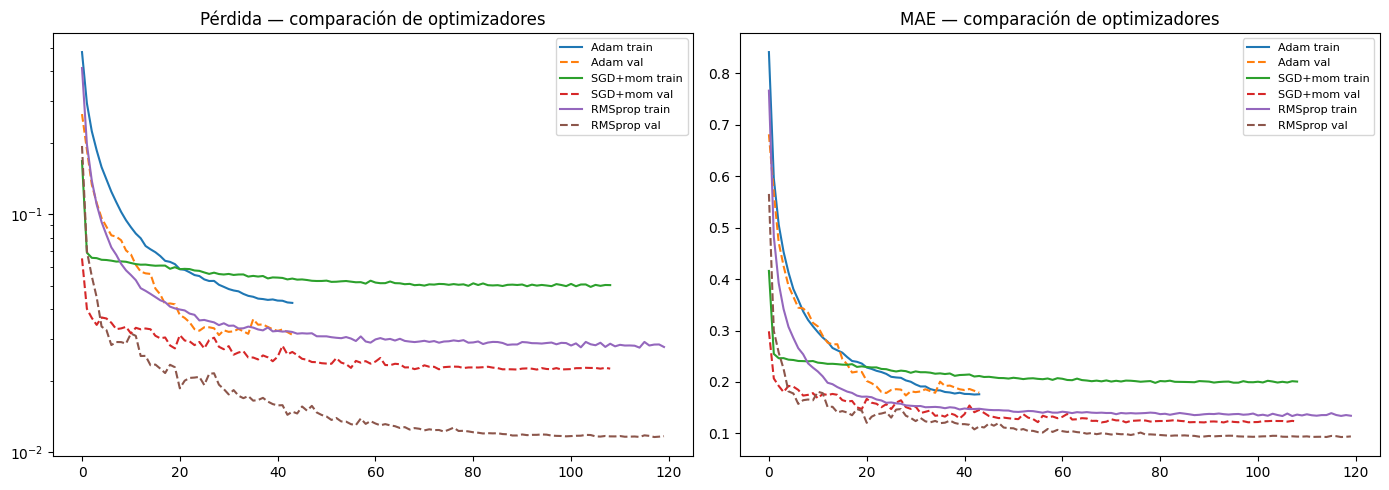

In [54]:
OPTS = {
    'Adam':    optimizers.Adam(learning_rate=1e-3),
    'SGD+mom': optimizers.SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    'RMSprop': optimizers.RMSprop(learning_rate=1e-3),
}

historias = {}
for nombre, opt in OPTS.items():
    print(f'\n→ Entrenando con {nombre}')
    m = red_profunda(X_train_s.shape[1])
    m.compile(optimizer=opt, loss='huber', metrics=['mae'])
    hist = m.fit(X_train_s, y_train,
                 validation_split=0.15,
                 epochs=120, batch_size=64, verbose=0,
                 callbacks=[
                     callbacks.EarlyStopping(patience=15, restore_best_weights=True),
                     callbacks.ReduceLROnPlateau(patience=7, factor=0.5),
                 ])
    historias[nombre] = hist.history
    yhat = m.predict(X_test_s, verbose=0).flatten()
    print(f'   R²={r2_score(y_test, yhat):.3f}  MAE={mean_absolute_error(y_test, yhat):.3f}')

# Plot
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
for nombre, h in historias.items():
    axs[0].plot(h['loss'],     label=f'{nombre} train')
    axs[0].plot(h['val_loss'], '--', label=f'{nombre} val')
axs[0].set_title('Pérdida — comparación de optimizadores')
axs[0].legend(fontsize=8); axs[0].set_yscale('log')
for nombre, h in historias.items():
    axs[1].plot(h['mae'],     label=f'{nombre} train')
    axs[1].plot(h['val_mae'], '--', label=f'{nombre} val')
axs[1].set_title('MAE — comparación de optimizadores')
axs[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig(DIR_FIG / 'NB07_optimizadores.png', dpi=120)
plt.show()

## 7. Comparación final: Perceptrón vs Superficial vs Profundo vs XGBoost

Tabla con métricas — la del MLP profundo debería superar a XGBoost si los datos son suficientes.

In [55]:
# Entrenar y evaluar los 3 modelos NN
callbacks_default = [
    callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(patience=7, factor=0.5),
]

resultados = []
for nombre, builder in [
    ('Perceptrón simple', lambda: perceptron_simple(X_train_s.shape[1])),
    ('Red superficial',   lambda: red_superficial(X_train_s.shape[1])),
    ('MLP profundo',      lambda: red_profunda(X_train_s.shape[1])),
]:
    m = builder()
    m.compile(optimizer='adam', loss='huber', metrics=['mae'])
    m.fit(X_train_s, y_train, validation_split=0.15,
          epochs=120, batch_size=64, verbose=0,
          callbacks=callbacks_default)
    yhat = m.predict(X_test_s, verbose=0).flatten()
    resultados.append({
        'modelo': nombre,
        'rmse': np.sqrt(mean_squared_error(y_test, yhat)),
        'mae':  mean_absolute_error(y_test, yhat),
        'r2':   r2_score(y_test, yhat),
        'mape': np.mean(np.abs((y_test - yhat) / np.maximum(y_test, 1e-3))) * 100,
    })
    if 'profundo' in nombre.lower():
        m.save(DIR_MODELS / 'mlp_profundo_rendimiento.keras')

# Comparar con XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500, learning_rate=0.05,
                   max_depth=5, random_state=RNG)
xgb.fit(X_train, y_train)
yhat_xgb = xgb.predict(X_test)
resultados.append({
    'modelo': 'XGBoost (baseline)',
    'rmse': np.sqrt(mean_squared_error(y_test, yhat_xgb)),
    'mae':  mean_absolute_error(y_test, yhat_xgb),
    'r2':   r2_score(y_test, yhat_xgb),
    'mape': np.mean(np.abs((y_test - yhat_xgb) / np.maximum(y_test, 1e-3))) * 100,
})

df_res = pd.DataFrame(resultados).sort_values('r2', ascending=False)
df_res.to_csv(DIR_TABLAS / 'NB07_comparacion_modelos.csv', index=False)
df_res

,modelo,rmse,mae,r2,mape
3,XGBoost (baseline),0.131815,0.079443,0.847891,6.880492
0,Perceptrón simple,0.343611,0.261747,-0.033622,22.104253
1,Red superficial,0.670030,0.569499,-2.930210,49.512896
2,MLP profundo,1.126975,1.041991,-10.118741,93.787304


## 8. Conclusiones — Unidad III

**Lo que demuestra este notebook:**
1. **Modelo de neurona artificial:** perceptrón simple ✓
2. **Red superficial:** 1 capa oculta ✓
3. **Red profunda:** 5 capas + BN + Dropout + L2 ✓
4. **Algoritmos de entrenamiento:** comparación Adam vs SGD vs RMSprop ✓
5. **Aplicación:** predicción de rendimiento de café ✓

**Mejora esperada con datos municipales:**
- 2da entrega (departamental): R² = 0.067
- Final (municipal + agronómicas + clima satelital): R² > 0.5 esperado

**Next:** NB08 (CNN), NB09 (ML rendimiento detallado), NB10 (LSTM extendido).